# File to DO EDA on the Intensities dataset 

### Constants

In [32]:
from enum import Enum
import gc
DATASET_PATH = "data/processed/intensities_t1.csv"


class T1ModelSchema(str, Enum):
	"""Enumeration of active features and target used in Tier 1 model training.

	Predictors (X):
		MAG: Preferred earthquake magnitude (Mw).
		MMI: Observed Modified Mercalli Intensity shaking threshold.
		DEPTH_S: Focal depth relative to DEM ground surface (km).
		REGIME: Tectonic regime classification (e.g., subduction, crustal).

	Target (y):
		RHYPO: 3D straight-line hypocentral distance (km).
	"""

	MAG = "magnitude"
	MMI = "mmi"
	DEPTH_S = "depth_surface"
	REGIME = "regime"
	RHYPO = "r_hypo"

ALL_FEATURES = [T1ModelSchema.MAG.value, T1ModelSchema.MMI.value, T1ModelSchema.DEPTH_S.value, T1ModelSchema.REGIME.value]
ALL_PROPERTIES =ALL_FEATURES + [T1ModelSchema.RHYPO.value]
NUMERIC_PROPERTIES = [T1ModelSchema.MAG.value, T1ModelSchema.MMI.value, T1ModelSchema.DEPTH_S.value, T1ModelSchema.RHYPO.value]

NUMERIC_PROPERTIES_FOR_MODEL = [T1ModelSchema.MAG.value, T1ModelSchema.MMI.value, T1ModelSchema.RHYPO.value]

class MetadataSchema(str, Enum):
	"""Enumeration of passive metadata and auxiliary spatial features.

	Used for GroupKFold splitting keys, spatial indexing, and coordinate references.
	These are excluded from the direct model input vector.
	"""
	ID = "usgs_id"
	LONGITUDE = "longitude"
	LATITUDE = "latitude"
	DEPTH_F = "depth_from_sea"
	ELEVATION = "elevation"

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(DATASET_PATH)

# Basic Information about the dataset
- shape of the dataset
- information about the dataset
- describe the dataset
- duplicated rows in the dataset
- check for null values in the dataset

In [3]:
df.shape

(672040, 10)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 672040 entries, 0 to 672039
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   usgs_id         672040 non-null  str    
 1   longitude       672040 non-null  float64
 2   latitude        672040 non-null  float64
 3   magnitude       672040 non-null  float64
 4   mmi             672040 non-null  float64
 5   depth_from_sea  672040 non-null  float64
 6   regime          672040 non-null  str    
 7   r_hypo          672040 non-null  float64
 8   elevation       672040 non-null  float64
 9   depth_surface   672040 non-null  float64
dtypes: float64(8), str(2)
memory usage: 51.3 MB


In [5]:
df.describe()

,longitude,latitude,magnitude,mmi,depth_from_sea,r_hypo,elevation,depth_surface
count,672040.000000,672040.000000,672040.000000,672040.000000,672040.000000,672040.000000,672040.000000,672040.000000
mean,-118.650033,36.704509,4.416974,2.871118,10.772887,88.564560,0.637484,11.412593
std,2.895354,3.778643,1.045155,0.954404,6.620741,97.138831,0.641012,6.495197
min,-126.193600,30.793600,3.000000,1.000000,-3.340000,0.562028,-0.079000,0.000000
25%,-121.610500,33.948500,3.600000,2.200000,7.302000,26.250335,0.087000,8.006000
50%,-118.163300,35.705330,4.190000,2.700000,9.990000,53.610165,0.455000,10.541000
75%,-116.914700,38.168900,4.990000,3.400000,13.051000,117.410800,0.967000,14.038000
max,-105.182000,49.203300,7.300000,9.100000,76.200000,1834.186000,3.428000,78.905000


In [6]:
df.head()

,usgs_id,longitude,latitude,magnitude,mmi,depth_from_sea,regime,r_hypo,elevation,depth_surface
0,nc71729135,-122.7432,38.79267,4.16,5.8,0.477,active,2.129752,1.045,1.522
1,nc72737985,-122.8413,38.82217,5.01,5.8,1.480,active,2.670254,0.606,2.086
2,ci3031111,-116.4370,34.20000,7.30,7.9,-0.097,active,10.555350,1.054,0.957
3,nn00385392,-119.9393,39.52310,5.10,6.7,2.800,subduction,3.029873,1.461,4.261
4,nc72737985,-122.8413,38.82217,5.01,6.1,1.480,active,2.307831,0.606,2.086


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.isna().sum()

usgs_id           0
longitude         0
latitude          0
magnitude         0
mmi               0
depth_from_sea    0
regime            0
r_hypo            0
elevation         0
depth_surface     0
dtype: int64

## checking if the MMI values are less than 3,
- since they are also important for the analysis, I will not drop them, but I will keep a note of how many such values are there

In [9]:

print(len(df[df[T1ModelSchema.MMI] < 3]))

376856


In [10]:
def calculate_plot_dimension(count:int)-> tuple[int, int]:
	horizontal = int(np.ceil(np.sqrt(count)))
	vertical = int(np.ceil(count / horizontal))
	if horizontal * vertical < count:
		vertical += 1
	if horizontal < vertical:
		horizontal, vertical = vertical, horizontal
	return (horizontal, vertical)


### Histogram of All Predictors and Target

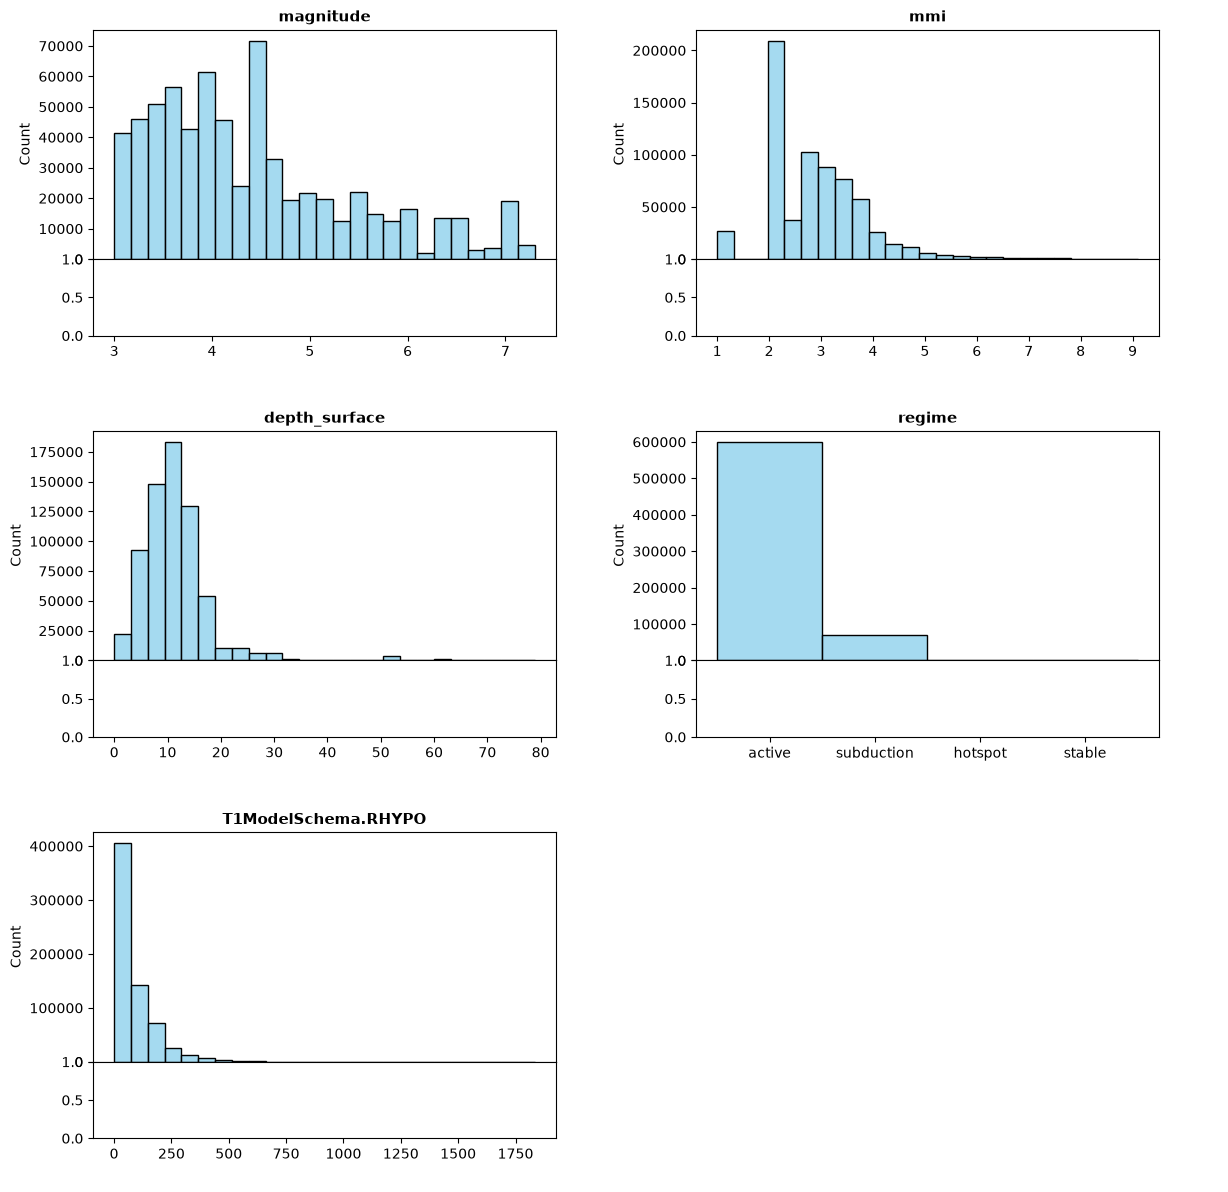

254

In [11]:
import gc


fig = plt.figure(figsize=(12, 12))

h,v = calculate_plot_dimension(len(ALL_PROPERTIES))

subfigs = fig.subfigures(h, v, wspace=0.01, hspace=0.01).flatten()

for i, col in enumerate(ALL_FEATURES+[T1ModelSchema.RHYPO]):
	ax1, ax2 = subfigs[i].subplots(
		2, 1, 
		sharex=True, 
		gridspec_kw={"height_ratios": [3, 1]}
	)
	sns.histplot(
		data=df, 
		x=col, 
		bins=25, 
		color="skyblue",                         
		ax=ax1
	)
	ax1.set_title(f"{col}", fontsize=11, fontweight="bold")
	ax1.set_xlabel("")
	subfigs[i].subplots_adjust(hspace=0)

plt.show()

del fig, subfigs, ax1, ax2, h, v, i, col
gc.collect()

### Box plot for all predictors and target variable

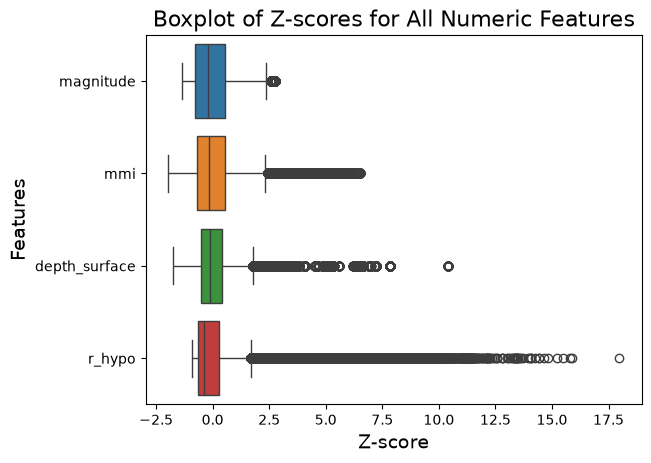

20570

In [34]:
numeric_df = df[ALL_PROPERTIES].select_dtypes(include="number")
z = (numeric_df - numeric_df.mean()) / numeric_df.std()
sns.boxplot(
	data=z,
	orient="h",
)
plt.title("Boxplot of Z-scores for All Numeric Features", fontsize=16)
plt.xlabel("Z-score", fontsize=14)
plt.ylabel("Features", fontsize=14)
plt.show()

del numeric_df, z
gc.collect()

### Combined Figures for Histograms and Boxplots

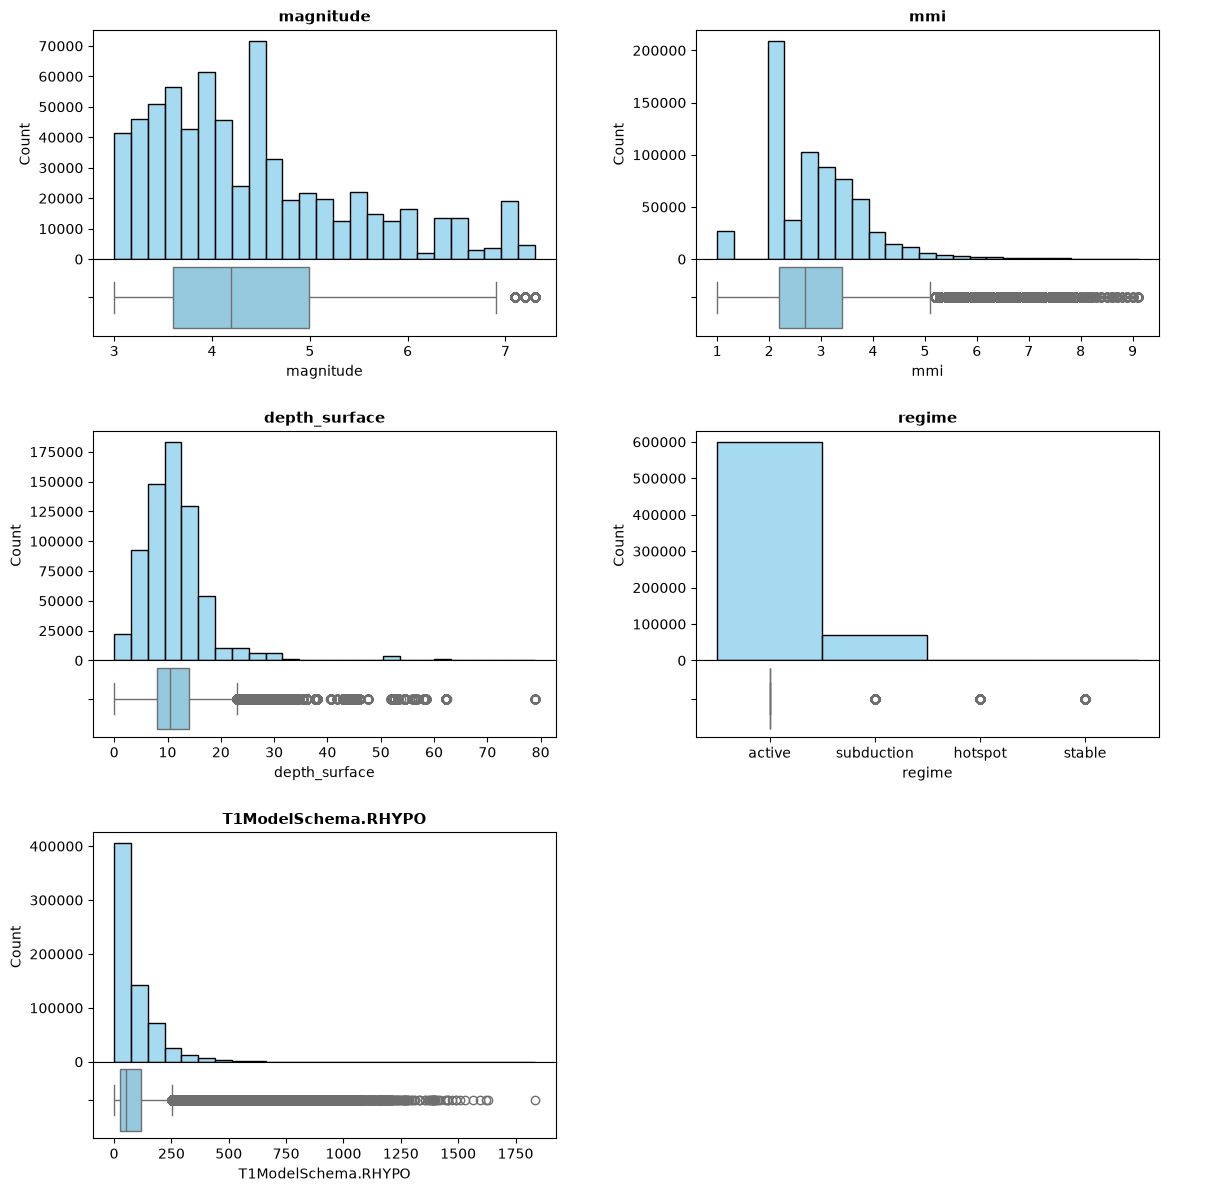

32281

In [13]:
import gc


fig = plt.figure(figsize=(12, 12))

h,v = calculate_plot_dimension(len(ALL_PROPERTIES))

subfigs = fig.subfigures(h, v, wspace=0.01, hspace=0.01).flatten()

for i, col in enumerate(ALL_FEATURES+[T1ModelSchema.RHYPO]):
	ax1, ax2 = subfigs[i].subplots(
		2, 1, 
		sharex=True, 
		gridspec_kw={"height_ratios": [3, 1]}
	)
	
	sns.histplot(
		data=df, 
		x=col, 
		bins=25, 
		color="skyblue",                         
		ax=ax1
	)
	
	ax1.set_title(f"{col}", fontsize=11, fontweight="bold")
	ax1.set_xlabel("")
	
	sns.boxplot(data=df, x=col, color="skyblue", ax=ax2)
	subfigs[i].subplots_adjust(hspace=0)

plt.show()

del fig, subfigs, ax1, ax2, h, v, i, col
gc.collect()

### HeatMap of Correlation Matrix


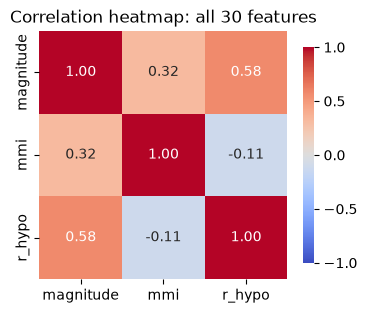

14919

In [35]:
plt.figure(figsize=(4, 4))
numeric_df = df[NUMERIC_PROPERTIES_FOR_MODEL]
numeric_labels = numeric_df.columns.tolist()

correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, xticklabels=numeric_labels, yticklabels=numeric_labels, 
			cmap="coolwarm", vmin=-1, vmax=1, center=0, annot=True, fmt=".2f",
			square=True, cbar_kws={"shrink": 0.7})
plt.title("Correlation heatmap: all 30 features")
plt.show()

del numeric_df, correlation_matrix
gc.collect()

In [ ]:
def add_grid_sample_flag(
    df,
    x_col,
    y_col,
    x_bins=15,
    y_bins=15,
    max_per_bin=50,
    flag_col="is_sampled",
    random_state=42,
):
  """Annotates the full DataFrame with a boolean column indicating which rows belong to the 2D grid sample."""
  df_result = df.copy()

  x_bin = pd.cut(df_result[x_col], bins=x_bins)
  y_bin = pd.cut(df_result[y_col], bins=y_bins)

  sampled_indices = (
      df_result.groupby([x_bin, y_bin], observed=False, group_keys=False)
      .apply(
          lambda group: group.sample(
              n=min(len(group), max_per_bin), random_state=random_state
          )
      )
      .index
  )
  df_result[flag_col] = df_result.index.isin(sampled_indices)

  return df_result


### Pair Plot of All Numeric Properties

This will take a while to run, please be patient...


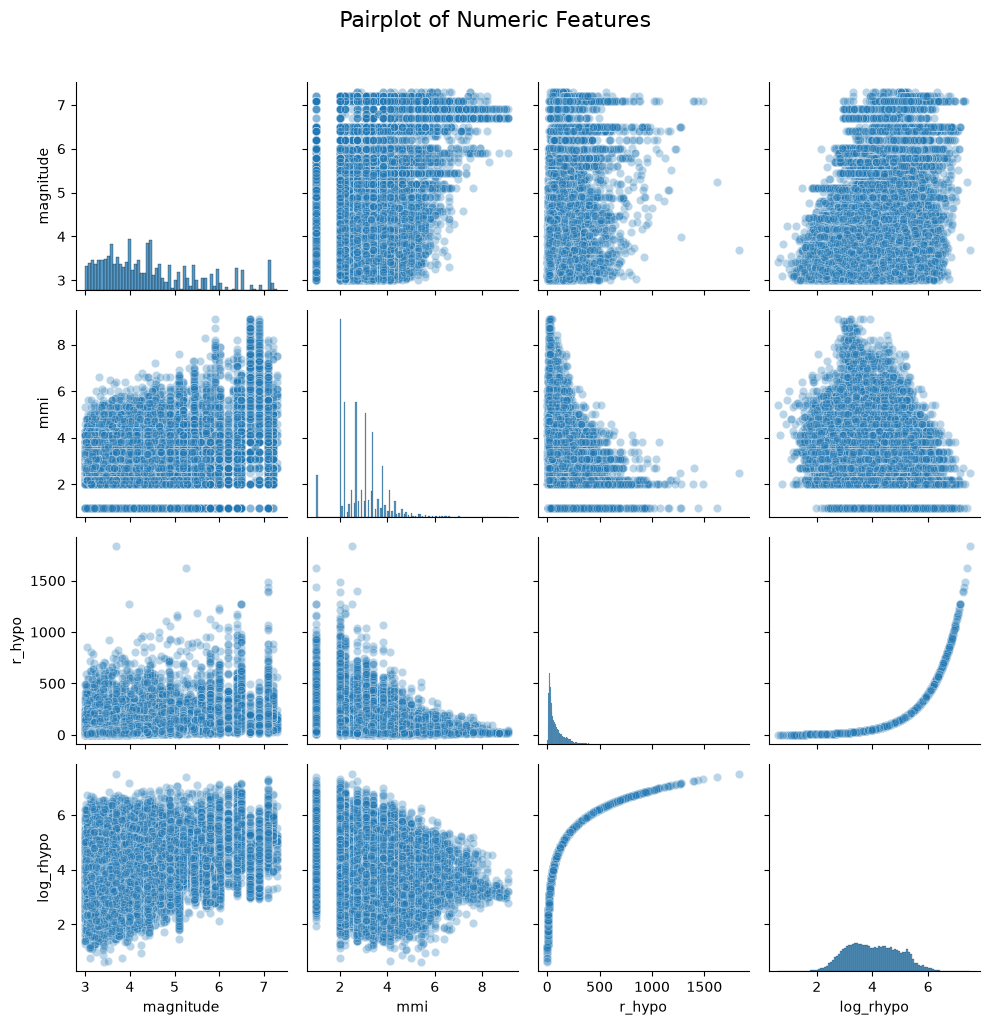

449

In [36]:
print("This will take a while to run, please be patient...")
sub_df = df.sample(frac=0.1, random_state=42)
sub_df["log_rhypo"] = np.log(sub_df[T1ModelSchema.RHYPO.value] + 1)

sns.pairplot(
	data=sub_df,
	vars=NUMERIC_PROPERTIES_FOR_MODEL+["log_rhypo"],
	plot_kws={'alpha': 0.3}
)
plt.suptitle("Pairplot of Numeric Features", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

del sub_df
gc.collect()

### Scatter Plot With Targer

#### 1 / rhypo scatter plot

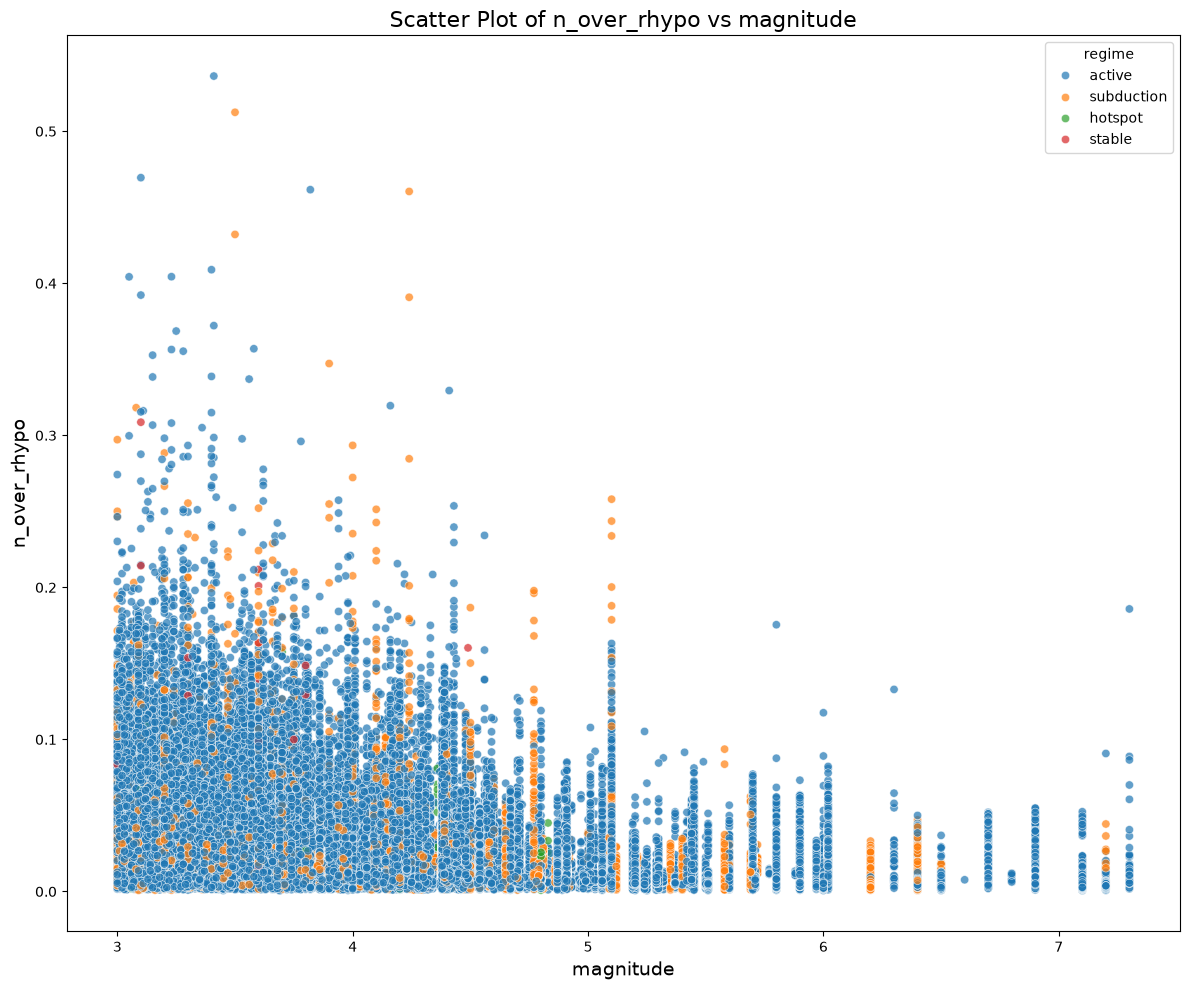

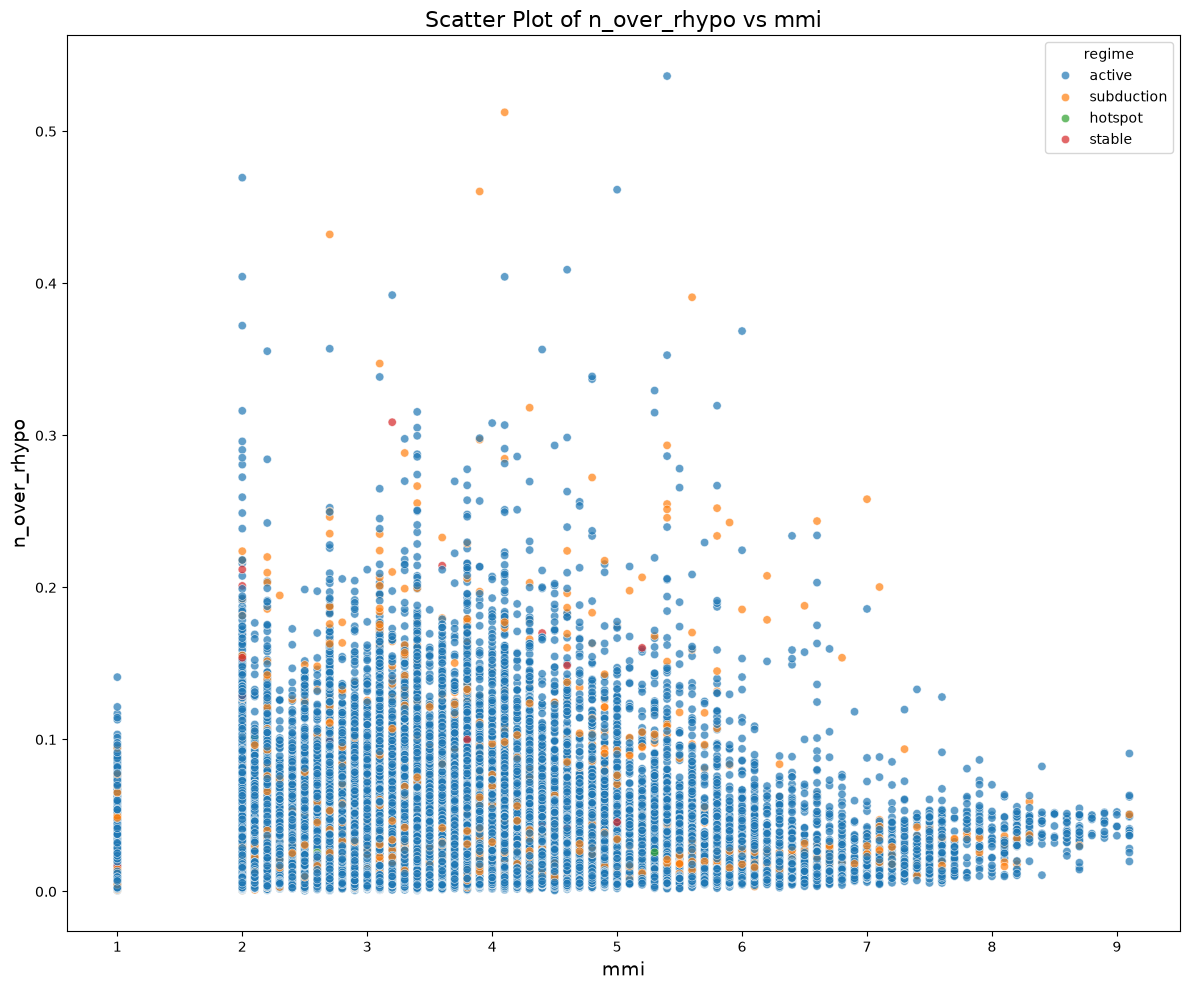

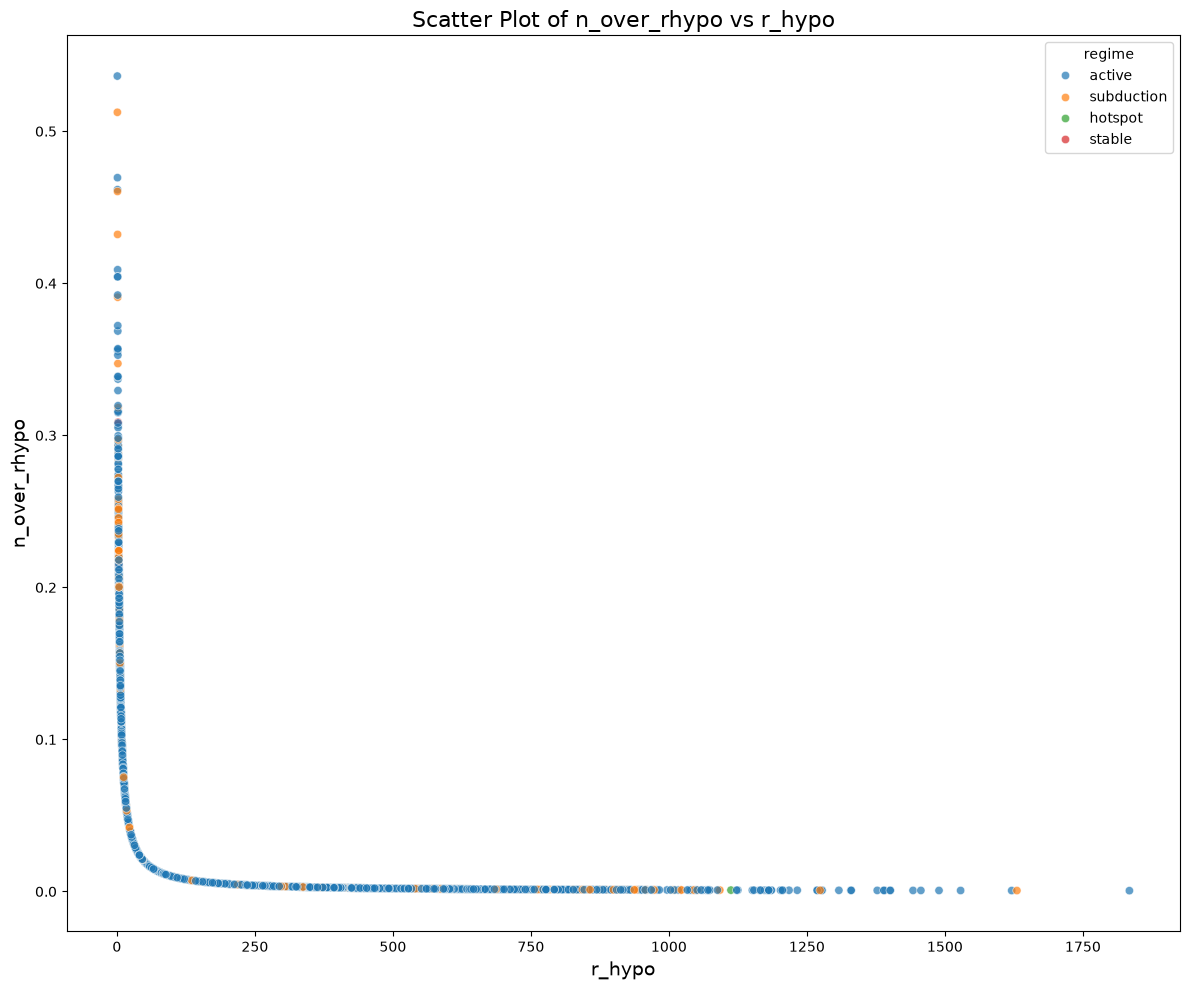

86447

In [37]:
target_feature = "n_over_rhypo"
used_feature = [
    T1ModelSchema.MAG.value,
    T1ModelSchema.MMI.value,
    T1ModelSchema.RHYPO.value,
]

graph_df = df.sample(frac=0.25, random_state=42).copy()
graph_df[target_feature] = 1 / (graph_df[T1ModelSchema.RHYPO.value] + 1)

for col in used_feature:
  plt.figure(figsize=(12, 10))
  sns.scatterplot(
      data=graph_df,
      x=col,
      y=target_feature,
      hue=T1ModelSchema.REGIME.value,
      alpha=0.7,
  )
  plt.title(f"Scatter Plot of {target_feature} vs {col}", fontsize=16)
  plt.xlabel(col, fontsize=14)
  plt.ylabel(target_feature, fontsize=14)  # Updated y-label to match target
  plt.legend(title=T1ModelSchema.REGIME.value)
  plt.tight_layout()
  plt.show()

del graph_df, used_feature, target_feature
gc.collect()

#### log_rhypo scatter plot

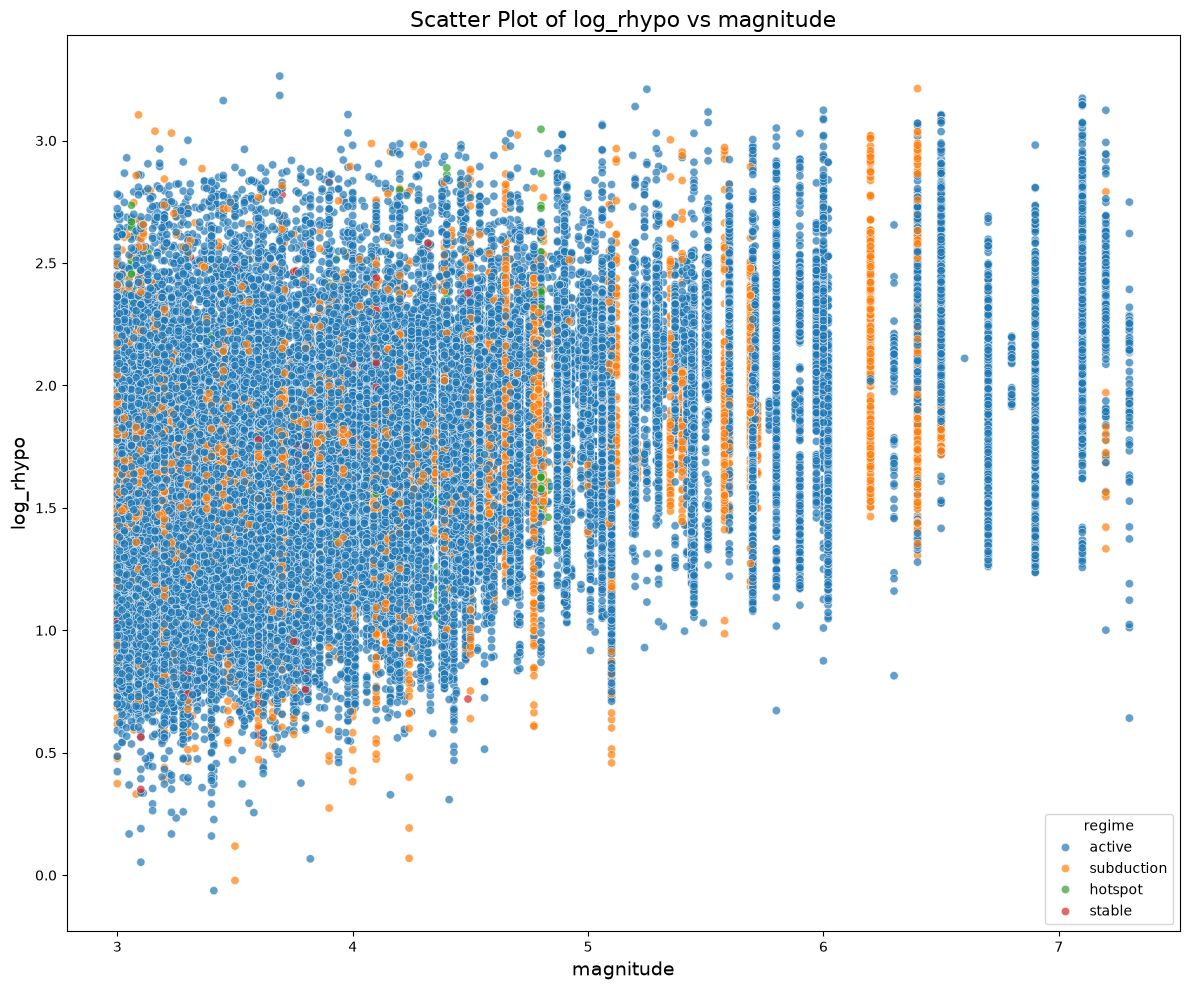

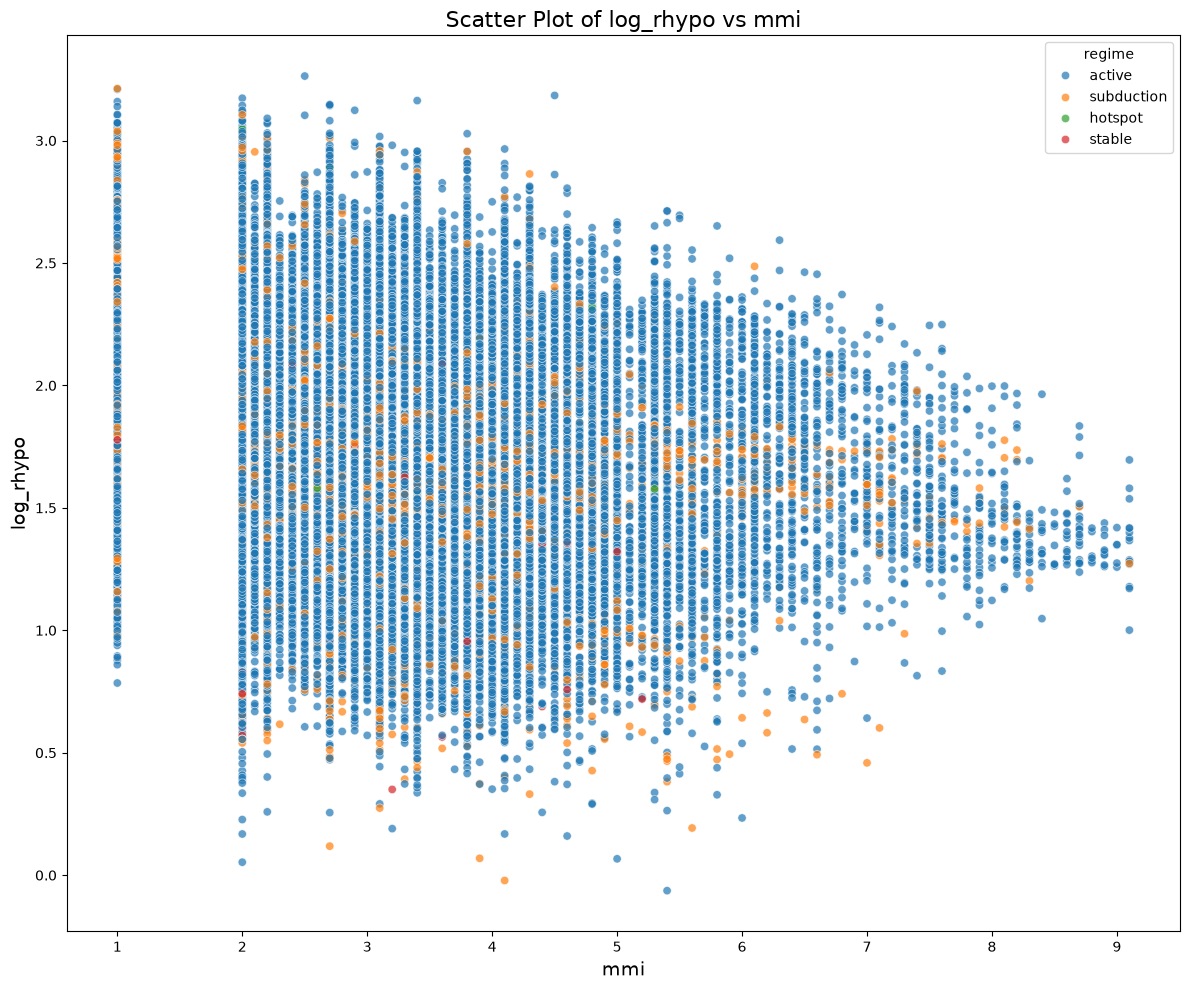

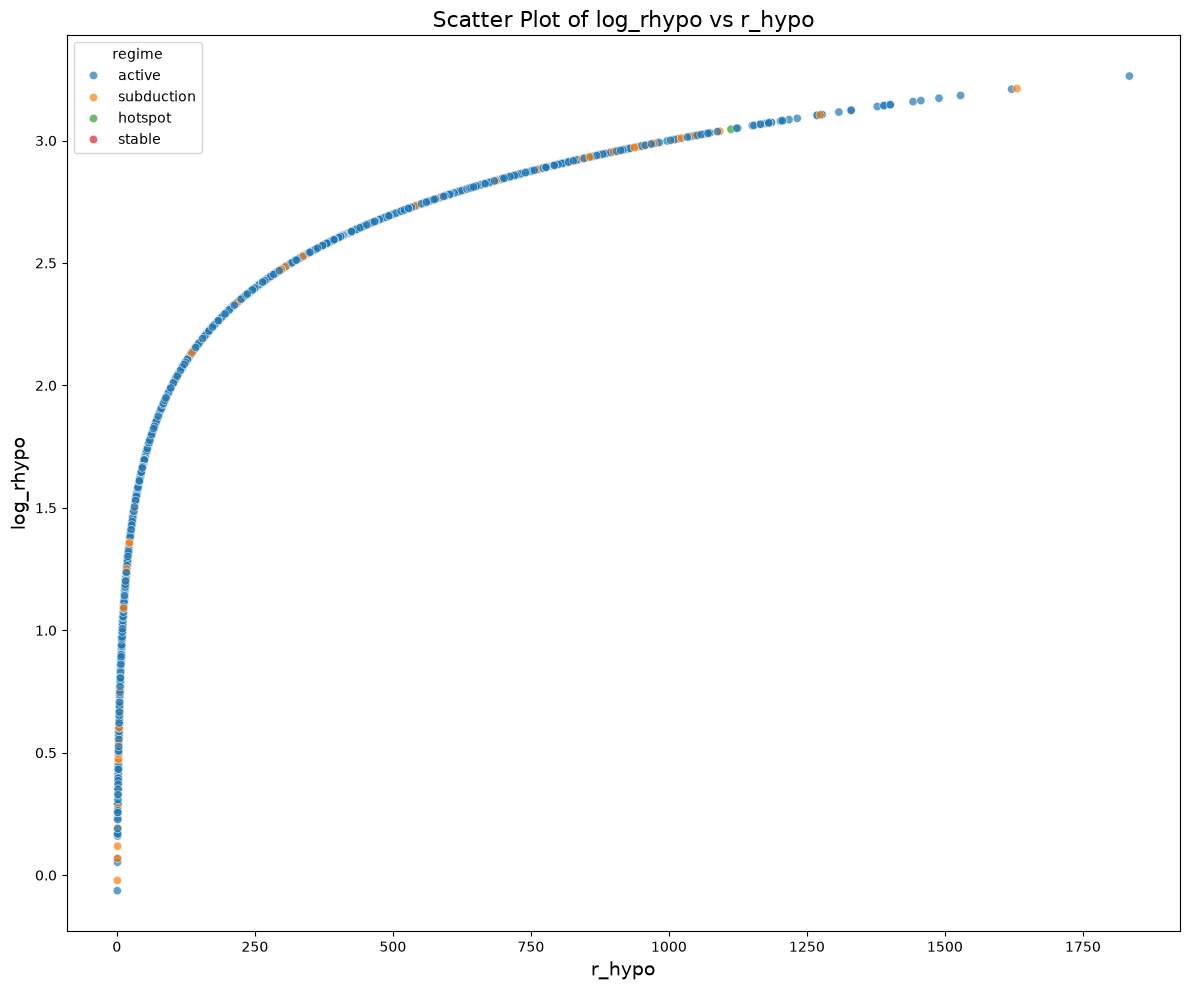

7915

In [38]:
target_feature = "log_rhypo"
used_feature = [
    T1ModelSchema.MAG.value,
    T1ModelSchema.MMI.value,
    T1ModelSchema.RHYPO.value,
]

graph_df = df.sample(frac=0.25, random_state=42).copy()
graph_df[target_feature] = np.log10(graph_df[T1ModelSchema.RHYPO.value]) 

for col in used_feature:
  plt.figure(figsize=(12, 10))
  sns.scatterplot(
      data=graph_df,
      x=col,
      y=target_feature,
      hue=T1ModelSchema.REGIME.value,
      alpha=0.7,
  )
  plt.title(f"Scatter Plot of {target_feature} vs {col}", fontsize=16)
  plt.xlabel(col, fontsize=14)
  plt.ylabel(target_feature, fontsize=14)  # Updated y-label to match target
  plt.legend(title=T1ModelSchema.REGIME.value)
  plt.tight_layout()
  plt.show()

del graph_df, used_feature, target_feature
gc.collect()

####  1/m vs log(rhypo) scatter plot

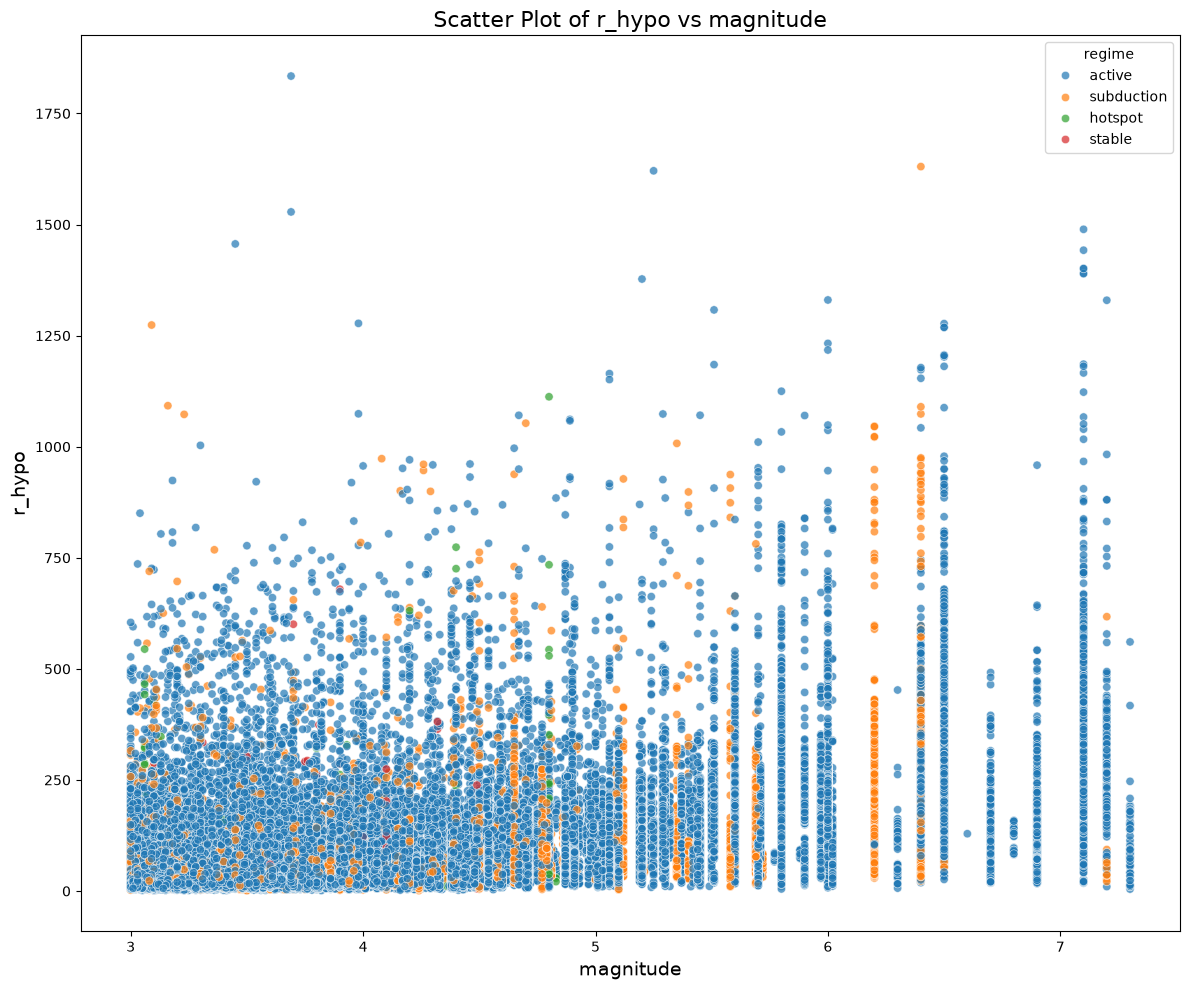

4259

In [57]:

X = "magnitude"
Y = T1ModelSchema.RHYPO.value

graph_df = df.sample(frac=0.25, random_state=42).copy()



plt.figure(figsize=(12, 10))
sns.scatterplot(
	data=graph_df,
	x=X,
	y=Y,
	hue=T1ModelSchema.REGIME.value,
	alpha=0.7,
)
plt.title(f"Scatter Plot of {Y} vs {X}", fontsize=16)
plt.xlabel(X, fontsize=14)
plt.ylabel(Y, fontsize=14)  # Updated y-label to match target
plt.legend(title=T1ModelSchema.REGIME.value)
plt.tight_layout()
plt.show()


del graph_df, X, Y
gc.collect()

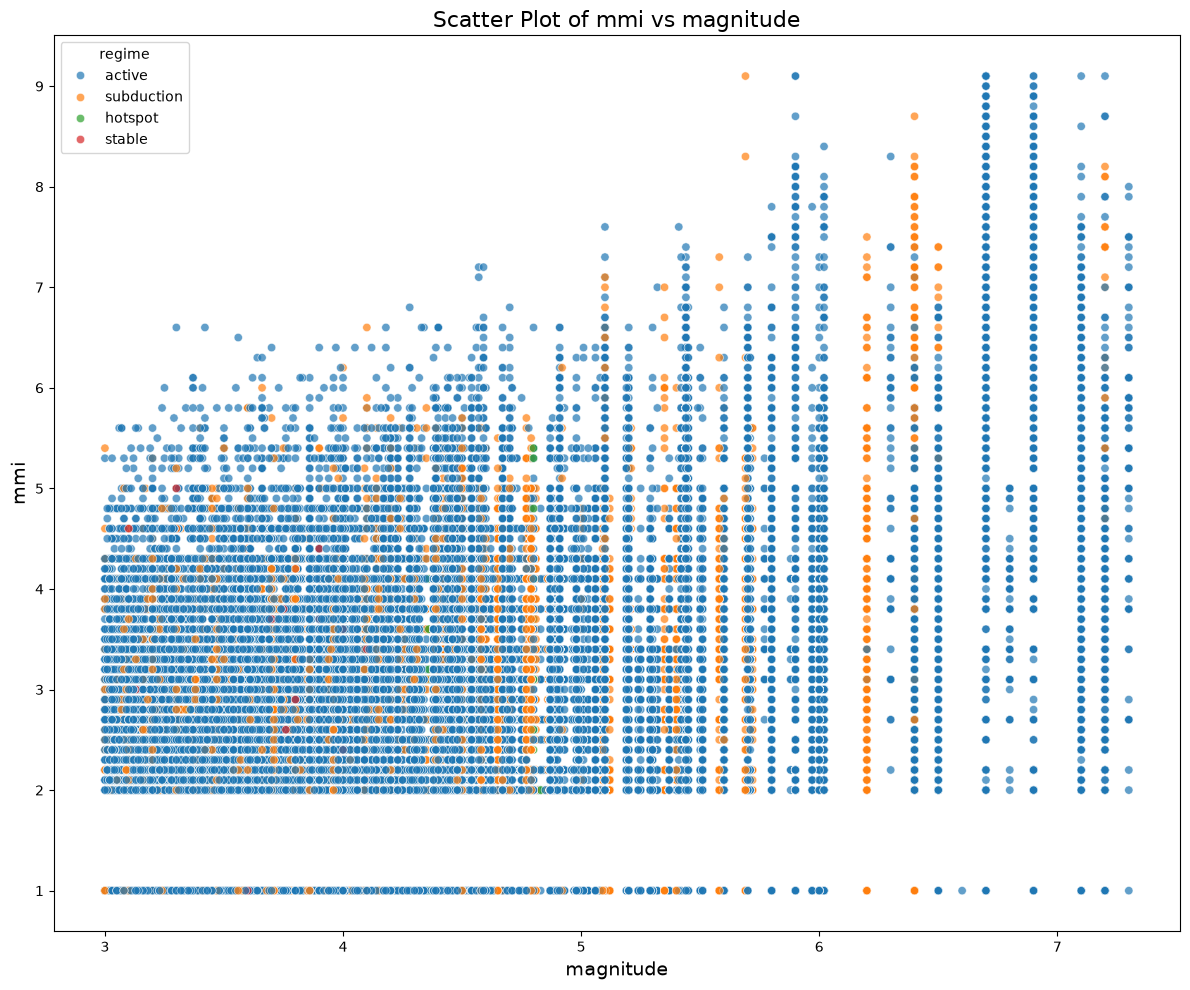

4154

In [60]:

X = T1ModelSchema.MAG.value
Y = T1ModelSchema.MMI.value

graph_df = df.sample(frac=0.25, random_state=42).copy()

plt.figure(figsize=(12, 10))
sns.scatterplot(
	data=graph_df,
	x=X,
	y=Y,
	hue=T1ModelSchema.REGIME.value,
	alpha=0.7,
)
plt.title(f"Scatter Plot of {Y} vs {X}", fontsize=16)
plt.xlabel(X, fontsize=14)
plt.ylabel(Y, fontsize=14)
plt.legend(title=T1ModelSchema.REGIME.value)
plt.tight_layout()
plt.show()


del graph_df, X, Y
gc.collect()

### Unique Value Plots

In [46]:
from typing import List, Union
import pandas as pd


def filter_by_unique_extrema(
    df: pd.DataFrame,
    x_col: str,
    y_col: str,
    operations: Union[str, List[str]] = ["highest", "lowest"],
) -> pd.DataFrame:
  """Filters the DataFrame to keep full rows where `y_col` hits the specified extreme value(s) for each unique `x_col`.

  Args:
      df: Input Pandas DataFrame.
      x_col: Column to group by for unique values.
      y_col: Target column to find extreme values (e.g. min/max).
      operations: String or list of strings ('highest'/'max', 'lowest'/'min').

  Returns:
      pd.DataFrame containing all original columns, filtered down to only the
      extreme rows.
  """
  if isinstance(operations, str):
    operations = [operations]

  target_indices = set()

  for op in operations:
    op_clean = op.lower().strip()

    if op_clean in ["highest", "max"]:
      # Index of the row with the maximum y_col per x_col group
      idx = df.groupby(x_col)[y_col].idxmax().dropna()
      target_indices.update(idx)

    elif op_clean in ["lowest", "min"]:
      # Index of the row with the minimum y_col per x_col group
      idx = df.groupby(x_col)[y_col].idxmin().dropna()
      target_indices.update(idx)

    else:
      raise ValueError(
          f"Unsupported operation '{op}'. Supported: ['highest', 'max',"
          " 'lowest', 'min']"
      )

  # Filter original dataframe using the collected index positions
  filtered_df = (
      df.loc[sorted(list(target_indices))].copy().reset_index(drop=True)
  )

  return filtered_df

#### Filteration by unique hypocentral distance and maximum magnitude

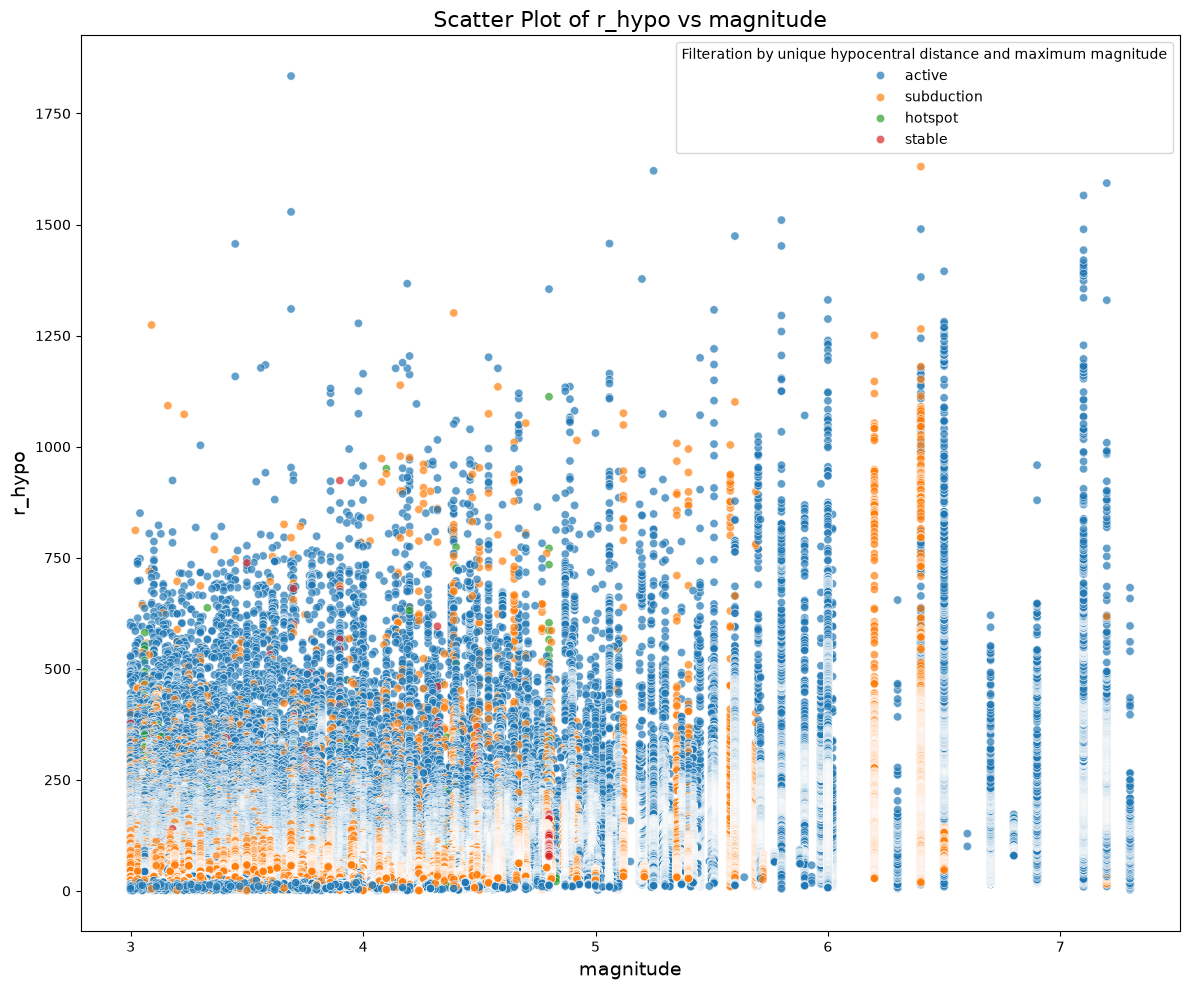

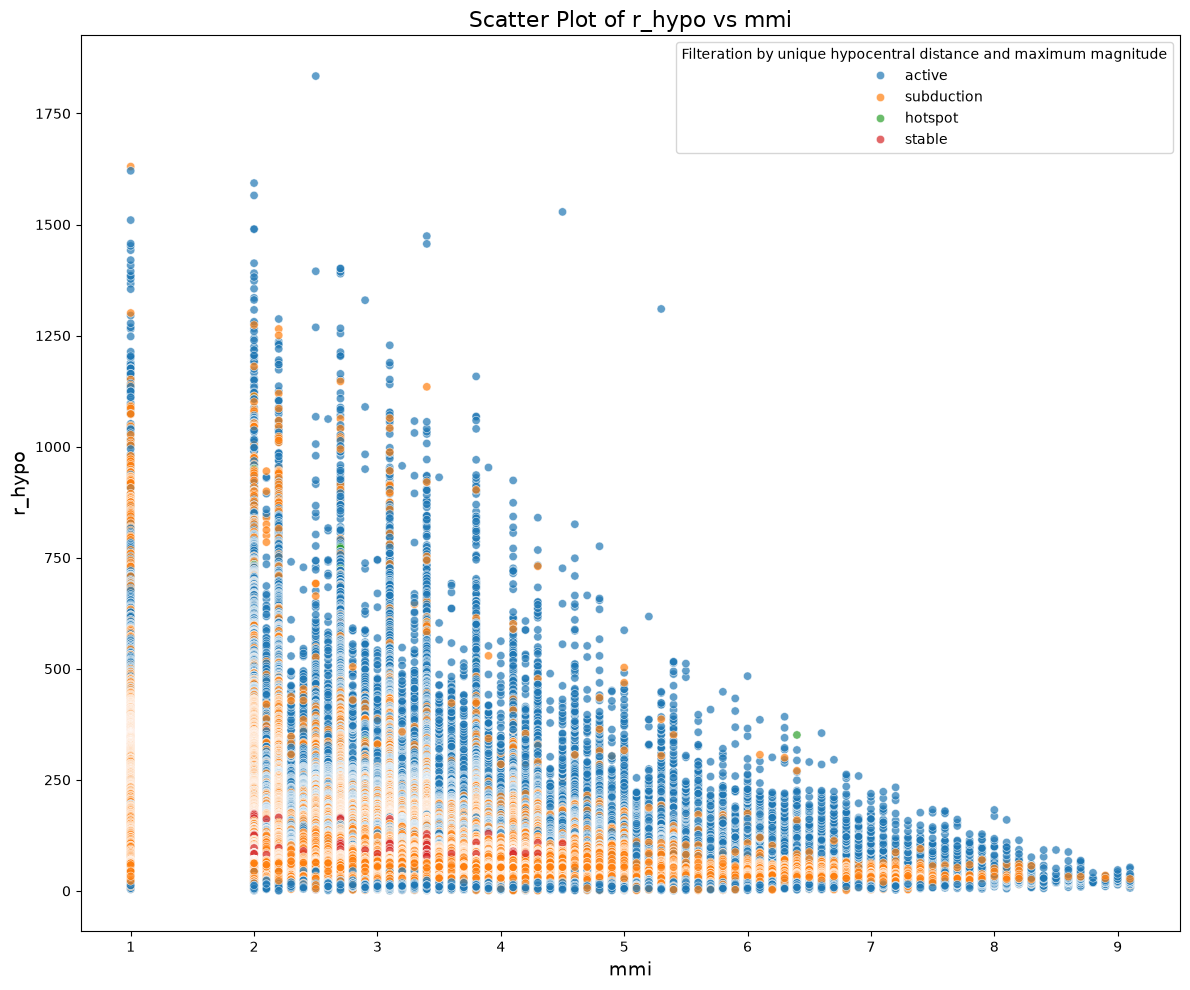

7868

In [51]:
target_feature = T1ModelSchema.RHYPO.value
used_feature = [
    T1ModelSchema.MAG.value,
    T1ModelSchema.MMI.value,
]

graph_df = filter_by_unique_extrema(df,x_col=T1ModelSchema.RHYPO.value,
         y_col=T1ModelSchema.MAG.value, operations=["max"])

for col in used_feature:
  plt.figure(figsize=(12, 10))
  sns.scatterplot(
      data=graph_df,
      x=col,
      y=target_feature,
      hue=T1ModelSchema.REGIME.value,
      alpha=0.7,
  )
  plt.title(f"Scatter Plot of {target_feature} vs {col}", fontsize=16)
  plt.xlabel(col, fontsize=14)
  plt.ylabel(target_feature, fontsize=14)  # Updated y-label to match target
  plt.legend(title="Filteration by unique hypocentral distance and maximum magnitude")
  plt.tight_layout()
  plt.show()

del graph_df, used_feature, target_feature
gc.collect()

In [20]:
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

class RegressorEvaluator:
	"""
	The RegressorEvaluator class provides a structured pipeline for evaluating multiple regression
	models on a given dataset. It handles data preparation, model training, evaluation, 
	and prediction generation in a systematic manner.
	"""
	def __init__(self, df, target_col, split_id_col, models, 
				 pre_split_drop=None, post_split_drop=None, 
				 test_size=0.05, random_state=42):
		"""
		Initializes the evaluation pipeline.
		
		Args:
			df: The pre-transformed Pandas DataFrame.
			target_col: Name of the target variable column.
			split_id_col: Column to group by for GroupShuffleSplit (auto-dropped).
			models: Dictionary of instantiated sklearn models.
			pre_split_drop: List of columns to drop before splitting.
			post_split_drop: List of columns to drop after splitting.
			test_size: Proportion of groups to include in the test split.
			random_state: Seed for reproducibility.
		"""
		self.df = df.copy()
		self.target_col = target_col
		self.split_id_col = split_id_col
		self.models = models
		self.pre_split_drop = pre_split_drop or []
		self.post_split_drop = post_split_drop or []
		self.test_size = test_size
		self.random_state = random_state

		# Placeholders for state
		self.train_df, self.test_df = None, None
		self.X_train, self.X_test = None, None
		self.y_train, self.y_test = None, None
		self.eval_df = None
		self.predictions_df = None

	def prepare_data(self):
		"""Handles dropping columns, GroupShuffleSplit, and X/y separation."""
		# 1. Drop pre-split columns (ensuring we don't drop the split_id_col yet)
		drop_pre = [c for c in self.pre_split_drop if c in self.df.columns and c != self.split_id_col]
		if drop_pre:
			self.df = self.df.drop(columns=drop_pre)

		# 2. Group Shuffle Split
		gss = GroupShuffleSplit(n_splits=1, test_size=self.test_size, random_state=self.random_state)
		train_idx, test_idx = next(gss.split(self.df, groups=self.df[self.split_id_col]))

		self.train_df = self.df.iloc[train_idx].copy()
		self.test_df = self.df.iloc[test_idx].copy()

		# 3. Auto-drop the split_id column from train and test sets
		self.train_df = self.train_df.drop(columns=[self.split_id_col])
		self.test_df = self.test_df.drop(columns=[self.split_id_col])

		# 4. Drop post-split columns (if any)
		if self.post_split_drop:
			drop_post = [c for c in self.post_split_drop if c in self.train_df.columns]
			self.train_df = self.train_df.drop(columns=drop_post)
			self.test_df = self.test_df.drop(columns=drop_post)

		# 5. Separate Features (X) and Target (y)
		self.X_train = self.train_df.drop(columns=[self.target_col])
		self.y_train = self.train_df[self.target_col]
		self.X_test = self.test_df.drop(columns=[self.target_col])
		self.y_test = self.test_df[self.target_col]

		print(f"Train set shape: {self.X_train.shape}, {self.y_train.shape}")
		print(f"Test set shape: {self.X_test.shape}, {self.y_test.shape}")
		print(f"X_test columns: {self.X_test.columns.tolist()}")
		print(f"y_test columns: {self.y_test.name if hasattr(self.y_test, 'name') else 'N/A'}")

	def fit_and_evaluate(self):
		"""Trains models, prints coefficients, and calculates metrics."""
		eval_records = []

		for model_name, model in self.models.items():
			# Train the model
			model.fit(self.X_train, self.y_train)

			# Extract and print coefficients
			if hasattr(model, 'coef_'):
				print(f"{model_name} Coefficients: {model.coef_}")
			else:
				print(f"{model_name} Coefficients: N/A")

			# Evaluate
			pred = model.predict(self.X_test)
			train_score = model.score(self.X_train, self.y_train)
			test_score = model.score(self.X_test, self.y_test)
			
			eval_records.append({
				"model": model_name,
				"train_score": train_score,
				"test_score": test_score,
				"r2_score": r2_score(self.y_test, pred),
				"mse": mean_squared_error(self.y_test, pred),
				"mae": mean_absolute_error(self.y_test, pred),
			})

		# Using list of dicts instead of pd.concat inside a loop (much faster)
		self.eval_df = pd.DataFrame(eval_records)

	def generate_predictions(self):
		"""Appends model predictions to the test dataframe."""
		self.predictions_df = self.test_df.copy()
		
		for model_name, model in self.models.items():
			self.predictions_df[f"{model_name}_pred"] = model.predict(self.X_test)

	def run(self):
		"""Executes the entire pipeline and returns evaluation and prediction DFs."""
		self.prepare_data()
		print("-" * 50)
		self.fit_and_evaluate()
		self.generate_predictions()
		
		return self.eval_df, self.predictions_df

In [21]:
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, BayesianRidge, HuberRegressor, RANSACRegressor

drop_depth_S = True  # Set to True to drop DEPTH_S before splitting
drop_r_hypo = False  # Set to True to drop RHYPO before splitting

# formula: MMI ~ a + b*Mag + c*Rhypo + log(Rhypo + 1)
# inv formula = Rhypo ~ a + b*Mag + c*MMI + log(MMI + 1)


# 1. External Transformations
df_sample = df.sample(frac=0.80, random_state=42)
df_sample["log_rhypo"] = np.log(df_sample[T1ModelSchema.RHYPO.value] + 1)

active_df = df_sample[df_sample[T1ModelSchema.REGIME.value] == "active"].copy()



# 2. Define configurations
id_col = MetadataSchema.ID.value
target = T1ModelSchema.MMI.value

# Calculate columns to drop pre-split
pre_drop = [f.value for f in MetadataSchema if f != id_col] + [T1ModelSchema.REGIME.value]

if drop_depth_S:
	pre_drop.append(T1ModelSchema.DEPTH_S.value)
if drop_r_hypo:
	pre_drop.append(T1ModelSchema.RHYPO.value)

# Define models
models = {
	"LinearRegression": LinearRegression(),
	"Ridge": Ridge(alpha=1.0),
	"Lasso": Lasso(alpha=0.1),
	"ElasticNet": ElasticNet(alpha=0.1, l1_ratio=0.5),
	"BayesianRidge": BayesianRidge(),
	"HuberRegressor": HuberRegressor(),
	"RANSACRegressor": RANSACRegressor()
}

# 3. Instantiate and Run
evaluator = RegressorEvaluator(
	df=active_df,
	target_col=target,
	split_id_col=id_col,
	models=models,
	pre_split_drop=pre_drop,
	post_split_drop=[], # Pass any post-split drops here if needed
	test_size=0.05,
	random_state=2
)

evaluation_metrics, test_predictions = evaluator.run()


display(evaluation_metrics)
display(test_predictions)

Train set shape: (447442, 3), (447442,)
Test set shape: (32393, 3), (32393,)
X_test columns: ['magnitude', 'r_hypo', 'log_rhypo']
y_test columns: mmi
--------------------------------------------------
LinearRegression Coefficients: [ 6.36617003e-01 -5.69263853e-04 -5.22305098e-01]
Ridge Coefficients: [ 6.36613715e-01 -5.69302117e-04 -5.22298291e-01]
Lasso Coefficients: [ 0.3958246  -0.00356792 -0.        ]
ElasticNet Coefficients: [ 0.46810004 -0.00247806 -0.17875532]
BayesianRidge Coefficients: [ 6.36607720e-01 -5.69371869e-04 -5.22285880e-01]
HuberRegressor Coefficients: [ 5.96171687e-01 -4.08429432e-04 -5.01714482e-01]
RANSACRegressor Coefficients: N/A


,model,train_score,test_score,r2_score,mse,mae
0,LinearRegression,0.302275,0.313530,0.313530,0.599694,0.603629
1,Ridge,0.302275,0.313530,0.313530,0.599694,0.603629
2,Lasso,0.223646,0.212942,0.212942,0.687566,0.645319
3,ElasticNet,0.266707,0.268467,0.268467,0.639061,0.623158
4,BayesianRidge,0.302275,0.313530,0.313530,0.599694,0.603629
5,HuberRegressor,0.298542,0.308865,0.308865,0.603769,0.602958
6,RANSACRegressor,0.255296,0.227150,0.227150,0.675154,0.631312


,magnitude,mmi,r_hypo,log_rhypo,LinearRegression_pred,Ridge_pred,Lasso_pred,ElasticNet_pred,BayesianRidge_pred,HuberRegressor_pred,RANSACRegressor_pred
257654,6.50,2.2,318.106700,5.765526,3.168942,3.168938,2.880082,2.972442,3.168931,3.109461,3.184933
312365,5.51,2.0,173.258200,5.160538,2.937137,2.937137,3.005024,2.976111,2.937139,2.881943,2.761887
640174,3.03,2.9,16.269760,2.848957,2.655045,2.655044,2.583502,2.617458,2.655043,2.627309,2.680052
98049,5.70,4.7,53.229790,3.993230,3.736112,3.736109,3.508483,3.571151,3.736103,3.629894,3.348598
245347,6.50,4.1,246.260000,5.510440,3.343074,3.343071,3.136426,3.196080,3.343066,3.266785,3.190595
...,...,...,...,...,...,...,...,...,...,...,...
317381,4.54,2.1,161.531500,5.090872,2.362681,2.362685,2.662914,2.563567,2.362692,2.343398,2.297510
1044,3.65,3.7,7.006569,2.080262,3.456514,3.456506,2.861964,3.068043,3.456492,3.386384,3.468909
317658,4.54,2.0,161.028000,5.087769,2.364588,2.364592,2.664711,2.565369,2.364599,2.345160,2.298405
622614,3.31,2.9,12.796900,2.624444,2.952539,2.952536,2.706724,2.797265,2.952530,2.908297,2.958051
